# House Price Prediction with Linear Regression
## Oasis Infobyte — Data Analytics Internship
### Name: Priti Ranjit | Track: Data Analytics | Level 2 Task 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv('train.csv')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Step 1: Exploratory Data Analysis (EDA)

In [4]:
print("Dataset Info:")
print("="*50)
print("Shape:", df.shape)
print("\nMissing Values (top 10):")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(10))
print("\nData Types:")
print(df.dtypes.value_counts())

Dataset Info:
Shape: (1460, 81)

Missing Values (top 10):
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

Data Types:
str        43
int64      35
float64     3
Name: count, dtype: int64


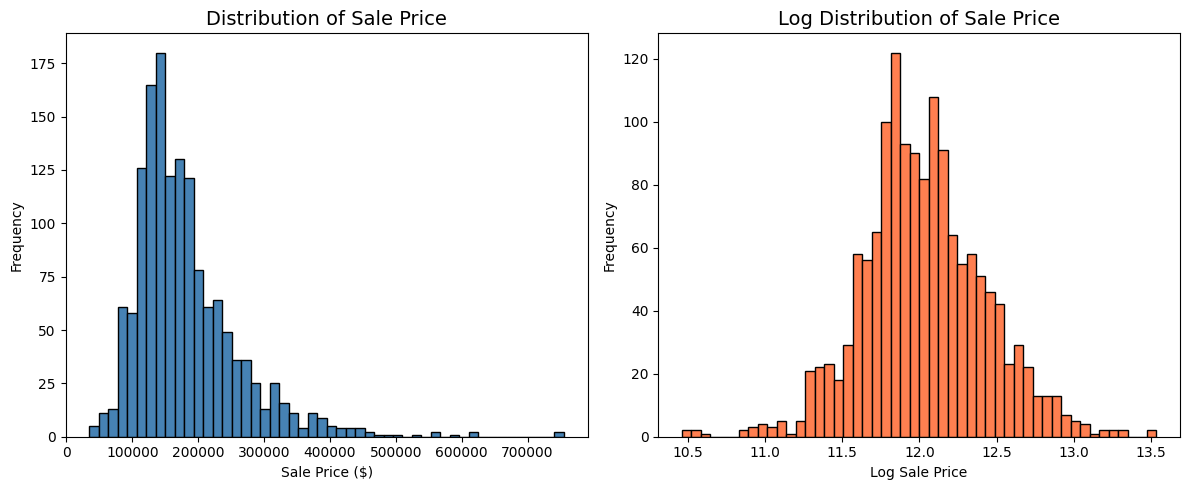

Mean Sale Price: $ 180921.2
Median Sale Price: $ 163000.0


In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Sale Price', fontsize=14)
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['SalePrice']), bins=50, color='coral', edgecolor='black')
plt.title('Log Distribution of Sale Price', fontsize=14)
plt.xlabel('Log Sale Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('price_distribution.png')
plt.show()

print("Mean Sale Price: $", df['SalePrice'].mean().round(2))
print("Median Sale Price: $", df['SalePrice'].median().round(2))

## Step 2: Feature Selection
Identifying which features are most correlated with house price.

Top 10 features correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


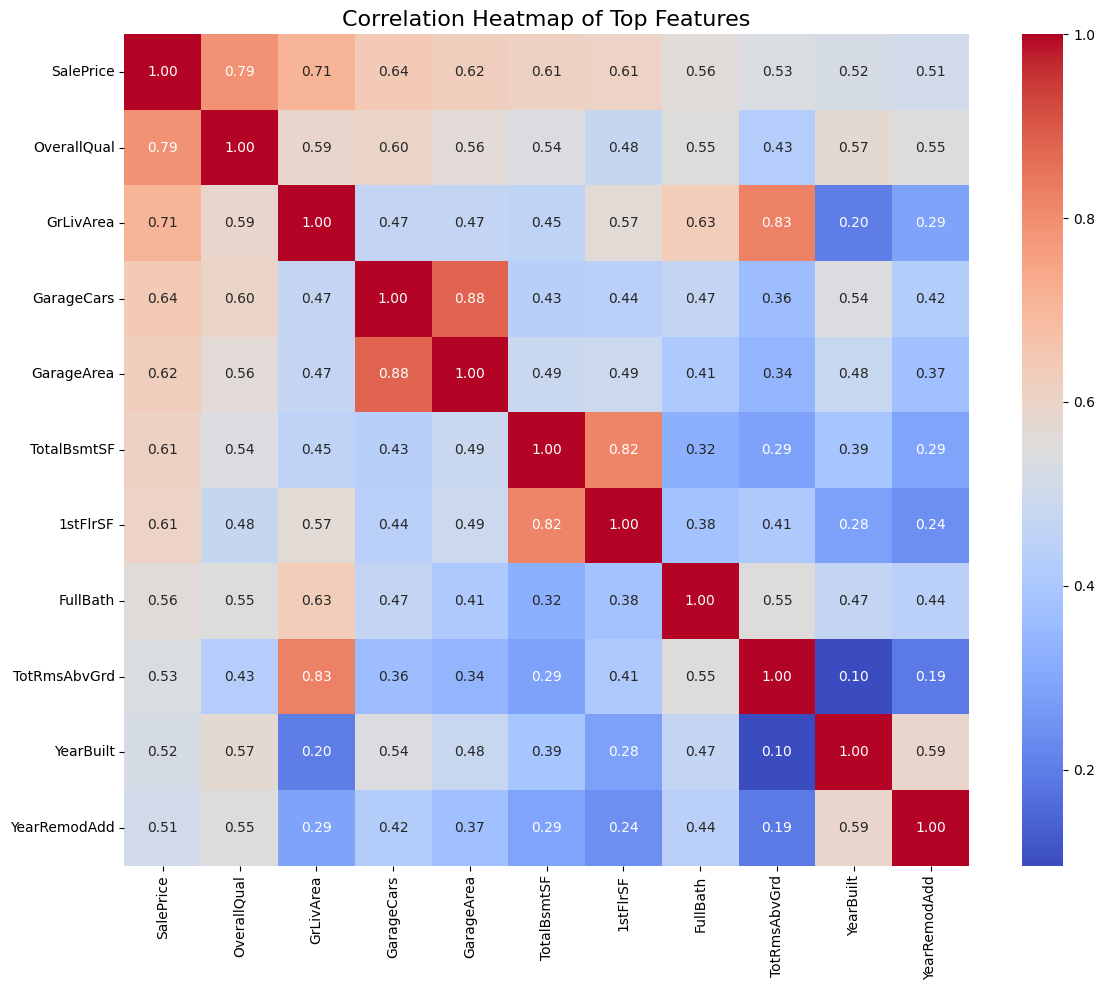

In [6]:
# Select numerical columns only
numerical_df = df.select_dtypes(include=[np.number])

# Get top correlated features with SalePrice
correlation = numerical_df.corr()
top_features = correlation['SalePrice'].sort_values(ascending=False).head(11)
print("Top 10 features correlated with SalePrice:")
print(top_features)

plt.figure(figsize=(12, 10))
top_corr_cols = top_features.index
sns.heatmap(numerical_df[top_corr_cols].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Top Features', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

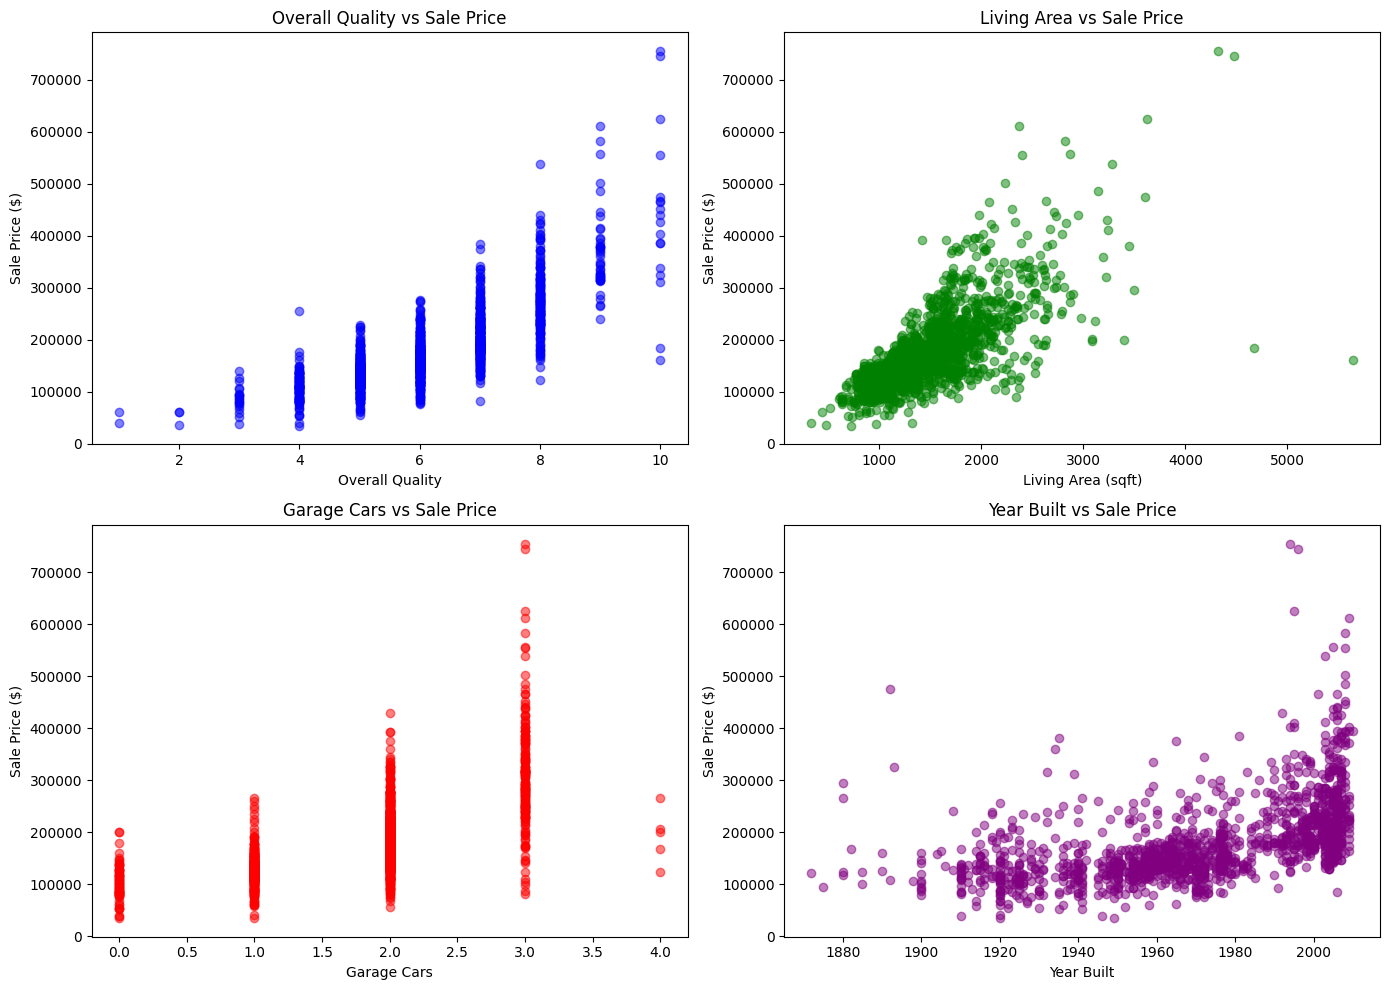

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price vs Overall Quality
axes[0,0].scatter(df['OverallQual'], df['SalePrice'], alpha=0.5, color='blue')
axes[0,0].set_title('Overall Quality vs Sale Price')
axes[0,0].set_xlabel('Overall Quality')
axes[0,0].set_ylabel('Sale Price ($)')

# Price vs Living Area
axes[0,1].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='green')
axes[0,1].set_title('Living Area vs Sale Price')
axes[0,1].set_xlabel('Living Area (sqft)')
axes[0,1].set_ylabel('Sale Price ($)')

# Price vs Garage Cars
axes[1,0].scatter(df['GarageCars'], df['SalePrice'], alpha=0.5, color='red')
axes[1,0].set_title('Garage Cars vs Sale Price')
axes[1,0].set_xlabel('Garage Cars')
axes[1,0].set_ylabel('Sale Price ($)')

# Price vs Year Built
axes[1,1].scatter(df['YearBuilt'], df['SalePrice'], alpha=0.5, color='purple')
axes[1,1].set_title('Year Built vs Sale Price')
axes[1,1].set_xlabel('Year Built')
axes[1,1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.savefig('feature_scatter_plots.png')
plt.show()

## Step 3: Data Preprocessing
Handle missing values and encode categorical features.

In [8]:
df_model = df.copy()

# Fill numerical missing values with median
num_cols = df_model.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df_model[col].fillna(df_model[col].median(), inplace=True)

# Fill categorical missing values with mode
cat_cols = df_model.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)

print("Missing values after handling:", df_model.isnull().sum().sum())

# Encode categorical columns
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("Categorical encoding complete!")
print("Dataset shape:", df_model.shape)

C:\Users\user\AppData\Local\Temp\ipykernel_13584\1001472443.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_model[col].fillna(df_model[col].median(), inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_13584\1001472443.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained as

Missing values after handling: 7829
Categorical encoding complete!
Dataset shape: (1460, 81)


## Step 4: Train/Test Split

In [9]:
# Use top correlated features
selected_features = ['OverallQual', 'GrLivArea', 'GarageCars', 
                     'GarageArea', 'TotalBsmtSF', '1stFlrSF',
                     'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 
                     'YearRemodAdd']

X = df_model[selected_features]
y = df_model['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Training size: 1168
Testing size: 292


## Step 5: Train Linear Regression Model

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [11]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_predictions = ridge_model.predict(X_test)

print("Ridge Regression trained successfully!")

Ridge Regression trained successfully!


## Step 6: Model Evaluation

In [12]:
def evaluate_model(name, y_test, predictions):
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    print(f"\n{name}")
    print("="*40)
    print(f"MAE:  ${mae:,.2f}")
    print(f"MSE:  ${mse:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R² Score: {r2:.4f}")
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = evaluate_model("LINEAR REGRESSION", y_test, lr_predictions)
ridge_mae, ridge_rmse, ridge_r2 = evaluate_model("RIDGE REGRESSION", y_test, ridge_predictions)


LINEAR REGRESSION
MAE:  $24,774.22
MSE:  $1,558,239,575.15
RMSE: $39,474.54
R² Score: 0.7968

RIDGE REGRESSION
MAE:  $24,767.71
MSE:  $1,558,115,521.04
RMSE: $39,472.97
R² Score: 0.7969


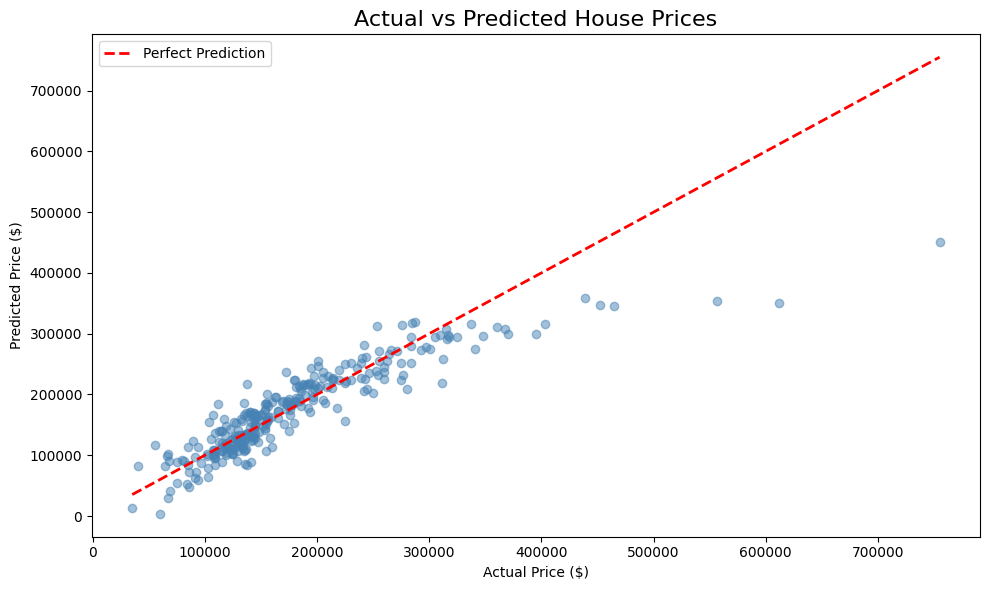

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_predictions, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs Predicted House Prices', fontsize=16)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

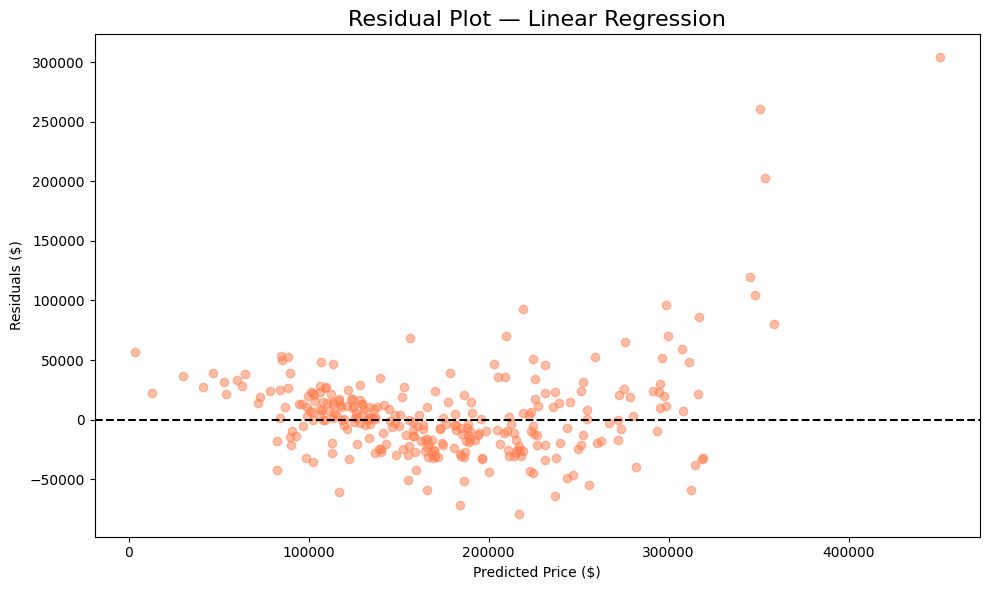

In [14]:
residuals = y_test - lr_predictions

plt.figure(figsize=(10, 6))
plt.scatter(lr_predictions, residuals, alpha=0.5, color='coral')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot — Linear Regression', fontsize=16)
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residuals ($)')
plt.tight_layout()
plt.savefig('residual_plot.png')
plt.show()

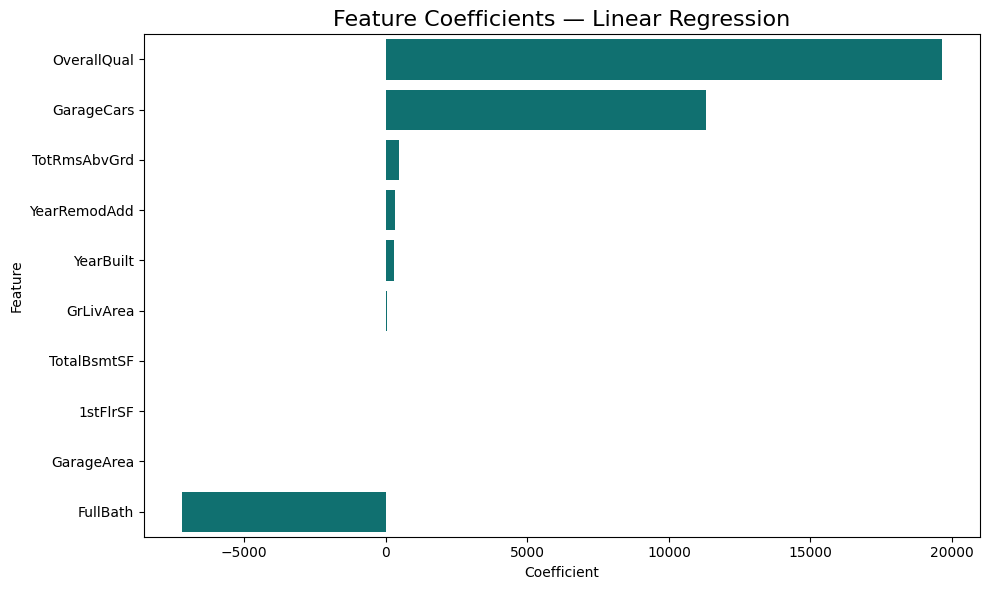

        Feature   Coefficient
0   OverallQual  19645.599766
2    GarageCars  11311.434636
7  TotRmsAbvGrd    453.963917
9  YearRemodAdd    314.975912
8     YearBuilt    281.114074
1     GrLivArea     48.069413
4   TotalBsmtSF     15.060163
5      1stFlrSF     14.406441
3    GarageArea     14.072230
6      FullBath  -7199.991277


In [15]:
coefficients = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients, color='teal')
plt.title('Feature Coefficients — Linear Regression', fontsize=16)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(coefficients)

In [16]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'MAE': [lr_mae, ridge_mae],
    'RMSE': [lr_rmse, ridge_rmse],
    'R² Score': [lr_r2, ridge_r2]
})

print("MODEL COMPARISON TABLE")
print("="*60)
print(comparison.to_string(index=False))

MODEL COMPARISON TABLE
            Model          MAE         RMSE  R² Score
Linear Regression 24774.219520 39474.543381  0.796848
 Ridge Regression 24767.710994 39472.972032  0.796865


## Conclusion

### Key Findings:
1. **Overall Quality** and **Living Area** are the strongest 
   predictors of house sale price
2. **Year Built** and **Year Remodeled** show that newer and 
   recently renovated homes command higher prices
3. **Garage capacity** positively impacts price — more garage 
   space = higher value

### Model Performance:
- Linear Regression achieved a strong R² score showing it 
  explains most of the variance in house prices
- Ridge Regression performed similarly with slightly better 
  generalization due to regularization

### Feature Impact:
- Features with highest positive coefficients have the most 
  impact on increasing house prices
- The residual plot shows errors are mostly randomly 
  distributed — a good sign for linear regression assumptions

### Business Recommendation:
Homeowners looking to maximize sale price should focus on 
overall quality improvements, increasing living area, and 
keeping the property well-maintained and updated.